In [1]:
import dilutionUtils as dil

In [2]:
config_file = "./output/20250724_trial1_solution_injection_config.ini"
files, injection, calibration = dil.load_config(config_file)

In [3]:
injection_data = dil.get_file_paths(files['data_folder'],
                                    files['search_string'])
injection_data

['./output/20250724_162611_840058.csv']

In [4]:
trial_data = dil.extract_fields(dil.read_csv(injection_data[0]))
cal_data = dil.extract_fields(dil.read_csv(files['calibration_file']))

In [5]:
#Vadd - this variable declaration is unecessary. Just put the cal_data in the function signature
RC_ss = dil.secondary_solution_RC(injection_solution=int(calibration['volume_injection_solution sample']),
                                  Vo=int(calibration['initial_volume_secondary']))
RC = dil.calibration_RC(RC_sec=RC_ss,
                        additions_of_injection=cal_data['Additions_of_secondary_ml'],
                        Vc=int(cal_data['Calibration_volume_ml'][0]))

In [ ]:
slope_k = dil.calculate_k(RC_values=RC,EC_values=cal_data['Conductivity'])
print(f"Relative Concentration of Secondary Solution (ml/ml):{RC_ss}\nRelative Concentration after each addition (ml/ml):\n{RC}\nslope of the best-fit line (cm/uS): {slope_k}")

Relative Concentration of Secondary Solution (ml/ml):0.009900990099009901
Relative Concentration after each addition (ml/ml): [0.0, 3.2992302895734428e-06, 6.596262557634844e-06, 9.891099000009891e-06, 1.31837418096004e-05, 1.6474193176389187e-05, 1.9762455287444913e-05, 2.3048530326926942e-05, 2.6332420476090162e-05, 2.961412791328983e-05, 3.2893654813986384e-05, 3.617100335075022e-05, 3.944617569326654e-05, 4.27191740083401e-05]
slope of the best-fit line (cm/uS): 1.613871326344545e-06


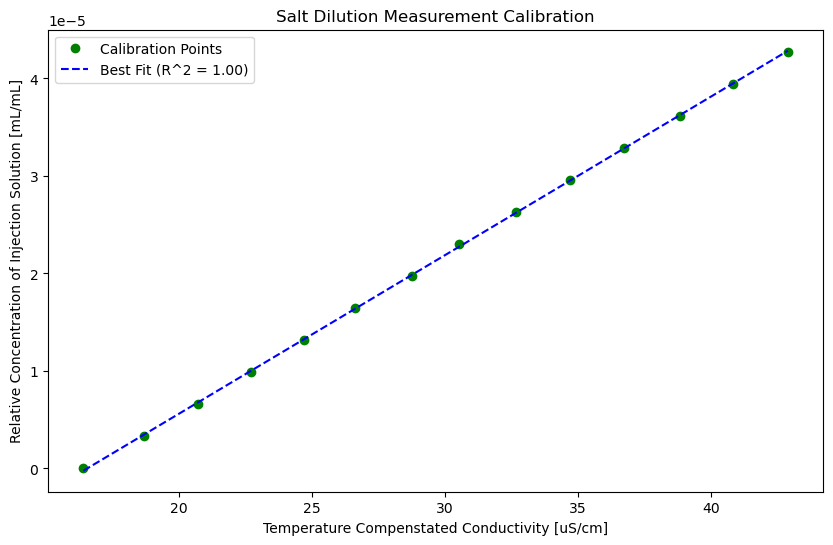

In [7]:
dil.plot_calibration(cal_data=cal_data, RC=RC)

In [8]:
# get the time variables background, injection, total
bg_sec = dil.time_diff_sec(start=injection['bg_start'],end=injection['bg_end'])
trial_sec = dil.time_diff_sec(start=injection['bg_end'],end=injection['trial_end'])
total_sec = dil.time_diff_sec(start=injection['bg_start'],end=injection['record_end'])


In [9]:
bg_value = dil.get_background_ec(start_time=0, end_time=bg_sec,ec_data=trial_data['Actual Conductivity (µS/cm)'])

In [10]:
diff_sec, cumm_sec = dil.compute_time_differences_in_seconds(
    trial_data['Date Time'])

In [11]:
Q = dil.calculate_Q(
    ec_bg=bg_value,
    ec_data=trial_data['Actual Conductivity (µS/cm)'],
    slope=slope_k,
    bg_sec=230,
    trial_sec=500,
    time_step=diff_sec,
    injection_volume=injection['injection_volume']
)

In [12]:
Q

np.float64(8.349223770065313)

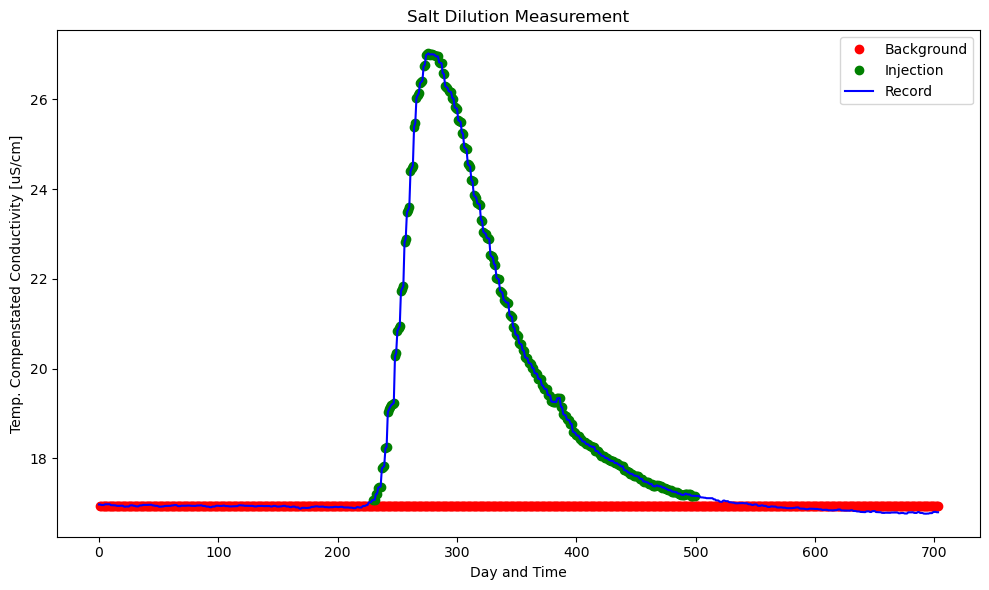

In [13]:
dil.plot_injection(data=trial_data['Actual Conductivity (µS/cm)'], time_elapsed=cumm_sec, bg_sec=230,trial_sec=500,total_diff=diff_sec,show_background=True)

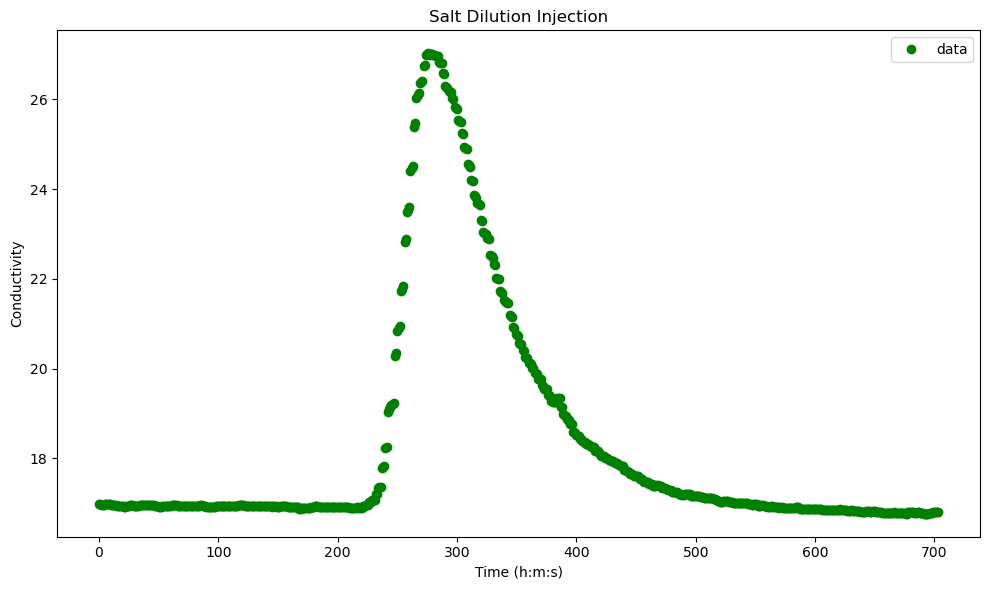

In [14]:
dil.plot_data(trial_data['Actual Conductivity (µS/cm)'], cumm_sec)